<h1 align="center"> Baseline Models </h1>

All radiomics data: paired + unpaired (validation).

<br>
<i> Import necessary libraries: <i>

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier 
import matplotlib.pyplot as plt
import sklearn.metrics as mx
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report

from src.optimise import capitalize_j, format_case_id

from collections import Counter

np.random.seed(2)

<i> Helper Functions: <i>

In [2]:
def spearman_df_function(features, target, threshold):
    feature_names = []
    feature_correlations = []
    
    column_names = features.columns.tolist()

    for column in column_names:
        corr, pval = spearmanr(features[column], target)
        if (corr >= threshold):
            feature_names.append(column)
            feature_correlations.append(corr)

    return feature_names, feature_correlations

def modelPerformance(confMat):
    TN = confMat[0, 0]
    TP = confMat[1, 1]
    FP = confMat[0, 1]
    FN = confMat[1, 0]
    prec = TP / (TP + FP)
    rec = TP / (TP + FN)
    spec = TN / (TN + FP)
    fpr = FP / (TN + FP)
    f1 = 2 * (prec * rec) / (prec + rec)
    acc = (TP + TN) / (TP + FP + TN + FN)
    return (acc, prec, rec, spec, fpr, f1)

def printPerformance(confMat):
    acc, prec, rec, spec, fpr, f1 = modelPerformance(confMat)
    print("Accuracy = " "%.4f" % acc)
    print("Precision = " "%.4f" % prec)
    print("Recall = " "%.4f" % rec)
    print("Specificity = " "%.4f" % spec)
    print("False positive rate = " "%.4f" % fpr)
    print("F1-score = " "%.4f" % f1)
    np.set_printoptions(precision=2)
    print("Confusion matrix (%):")
    print(confMat/np.sum(confMat)*100)

def proximityMatrix(mdl, X, normalize=True):      
    endNode = mdl.apply(X)
    nTrees = endNode.shape[1]
    n = X.shape[0]
    proxMat = np.zeros((n,n))
    for k in range(0, nTrees):
        a = endNode[:,k]
        proxMat += 1*np.equal.outer(a, a)
    if normalize:
        proxMat = proxMat / nTrees
    return proxMat

### Matching Samples for Analysis

In [3]:
# Step 1: Load RNA-Seq data
df_rna = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/rna_counts/RNA_counts_141024.csv", header=None, low_memory=False)
df_rna_transposed = df_rna.transpose()
new_header = df_rna_transposed.iloc[1]
df_rna_transposed = df_rna_transposed[2:]
df_rna_transposed.columns = new_header
df_rna_transposed.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces

# Step 3: Filter RNA data for 'ENSG' columns
rna_cols = df_rna_transposed.filter(like='ENSG')

# Step 4: Load and merge image data
df_images = pd.read_excel("/home/kryan24/MRes_Ultrasound/data/metadata/RNA_Sample_Linking2.xlsx")
df_images.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces
df_images['Sample ID'] = df_images['Sample ID'].str.replace(' ', '_')
df_images["SURGICAL"] = df_images["SURGICAL"].str.strip() # Remove whitespaces from SURGICAL

df_merged = pd.merge(df_images, df_rna_transposed, left_on="Sample ID", right_on="Geneid")

df_merged_copy = df_merged

# Step 5: Correct data quality issues
df_merged["Extraction site"] = df_merged["Extraction site"].str.strip()
df_merged["Extraction site"] = df_merged["Extraction site"].str.lower()

# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)

# Filter columns
df_radiomics = df_radiomics.drop(df_radiomics.iloc[:, 3907:3950], axis=1)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED

# Step 7: Match radiomics data to metadata and filter DataFrame
df_radiomics_meta = df_merged[["Extraction site", "SURGICAL", "CASE ID", "CASE ID2"]]

# Step 8: Merge DataFrames
df_merged2 = pd.merge(df_radiomics_meta, df_radiomics, left_on="CASE ID", right_on="ID")

# Step 9: Correct data quality issues
df_merged2 = df_merged2.drop(["ID"], axis=1)

# Step 10: Keep the same samples for RNA as radiomics data
case_id_list = df_merged2["CASE ID"].tolist()
mask = df_merged["CASE ID"].isin(case_id_list)
df_merged = df_merged[mask]

In [4]:
# Check length of both paired sample dataframes
print("Number of rows in paired radiomics samples:", df_merged2.shape[0])
print("Number of rows in paired RNA samples:", df_merged.shape[0])

Number of rows in paired radiomics samples: 36
Number of rows in paired RNA samples: 36


### Pair Images and RNA data

In [5]:
# Filter radiomics data 
rad_cols = df_merged2.drop(["Extraction site", "SURGICAL", "CASE ID", "CASE ID2", "MAHCINE_CORECCTED"], axis=1)

# Step 1: Prepare image filenames and filter data
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames_rna = []
image_filenames_rad = []
rna_data_filtered = []
rad_data_filtered = []
surgical_rna = []
surgical_rad = []
sample_count_rna = 0 
sample_count_rad = 0 

rna_paired_id_list = []
rad_paired_id_list = [] 

In [6]:
for index, row in df_merged.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected):
                    image_filenames_rna.append(file_name)
                    rna_data_filtered.append(
                        row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rna.append(row["SURGICAL"])
                    rna_paired_id_list.append(case_id)
                    sample_count_rna += 1
                    break  # Only use the first matching image for each row

                if (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rna.append(file_name)
                    rna_data_filtered.append(
                        row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rna.append(row["SURGICAL"])
                    rna_paired_id_list.append(case_id2)
                    sample_count_rna += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rna)

Number of Samples:  29


In [7]:
for index, row in df_merged2.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected):
                    image_filenames_rad.append(file_name)
                    rad_data_filtered.append(
                        row[rad_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rad.append(row["SURGICAL"])
                    rad_paired_id_list.append(case_id)
                    sample_count_rad += 1
                    break  # Only use the first matching image for each row

                if (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rad.append(file_name)
                    rad_data_filtered.append(
                        row[rad_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rad.append(row["SURGICAL"])
                    rad_paired_id_list.append(case_id2)
                    sample_count_rad += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rad)

Number of Samples:  29


In [8]:
flag = (surgical_rna == surgical_rad)
print(f"Matching Diagnoses: ", flag)

flag2 = (image_filenames_rna == image_filenames_rad)
print(f"Matching Images: ", flag2)

flag3 = (rna_paired_id_list == rad_paired_id_list)
print(f"Matching IDs: ", flag3)

Matching Diagnoses:  True
Matching Images:  True
Matching IDs:  True


In [9]:
# Create DataFrame for surgical matching
match_dict = {"image_name": image_filenames_rad, "ID": rad_paired_id_list, "SURGICAL": surgical_rad} 
match_df = pd.DataFrame(match_dict)
match_df

,image_name,ID,SURGICAL
0,12930_3.nii.gz,12930,B-S
1,13291_0010.nii.gz,13291,M-S
2,14023_3.nii.gz,14023,M-S
3,14056_3.nii.gz,14056,M-S
4,14654_3.nii.gz,14654,M-S
5,14024_2.nii.gz,14024,M-S
6,14984_0039.nii.gz,14984,M-S
7,16106_0022.nii.gz,16106,B-S
8,16134_0049.nii.gz,16134,M-S
9,16208_1.nii.gz,16208,B-S


### Get Unpaired Images and RNA Data 
(_validation_)

In [10]:
# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)
# Filter columns
surg_placeholder = df_radiomics["SURGICAL"]
df_radiomics = df_radiomics.drop(df_radiomics.iloc[:, 3907:3950], axis=1)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED
df_radiomics.insert(0, "SURGICAL", surg_placeholder)
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].str.strip() 
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].replace(["B-NS", "B-NS -->THEATRE"], "B-S")
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].replace(["M-NS"], "M-S")
df_radiomics = df_radiomics.loc[df_radiomics["SURGICAL"] != "NS"]
df_radiomics["ID"] = df_radiomics["ID"].astype(str)

In [11]:
rad_paired_id_list_noj = list(map(lambda x: "26246" if x == "J630" else x, rad_paired_id_list))
df_unpaired_rad = df_radiomics[~df_radiomics["ID"].isin(rad_paired_id_list_noj)]
df_unpaired_rna = df_merged_copy[~df_merged_copy["CASE ID"].isin(rna_paired_id_list) & ~df_merged_copy["CASE ID2"].isin(rna_paired_id_list)]


In [12]:
# Check length of both unpaired sample dataframes
print("Number of rows in unpaired radiomics samples:", df_unpaired_rad.shape[0])
print("Number of rows in unpaired RNA samples:", df_unpaired_rna.shape[0])

Number of rows in unpaired radiomics samples: 547
Number of rows in unpaired RNA samples: 38


In [13]:
check1 = df_unpaired_rad["ID"].to_list()
check2 = rad_paired_id_list
set(check1) & set(check2)

set()

In [14]:
check1 = df_unpaired_rna["CASE ID"].to_list() + df_unpaired_rna["CASE ID2"].to_list()
check2 = rna_paired_id_list
set(check1) & set(check2)

set()

In [15]:
# Create DataFrame for surgical matching
match_rad_dict = {"CASE ID": df_unpaired_rad["ID"].astype("int64"), "SURGICAL": df_unpaired_rad["SURGICAL"]} 
match_rad_df = pd.DataFrame(match_rad_dict)
match_rad_df

,CASE ID,SURGICAL
0,11935,B-S
1,12041,B-S
2,12165,B-S
3,12287,M-S
4,12665,M-S
...,...,...
572,756,B-S
573,757,B-S
574,759,B-S
575,760,M-S


In [16]:
# Create DataFrame for surgical matching
match_rna_dict = {"CASE ID": df_unpaired_rna["CASE ID"], "CASE ID2": df_unpaired_rna["CASE ID2"], "SURGICAL": df_unpaired_rna["SURGICAL"]} 
match_rna_df = pd.DataFrame(match_rna_dict)
match_rna_df

,CASE ID,CASE ID2,SURGICAL
0,12930,NaN,B-S
1,13291,NaN,M-S
2,13750,NaN,M-S
3,14023,NaN,M-S
4,14056,NaN,M-S
5,14654,NaN,M-S
6,14024,NaN,M-S
7,14984,NaN,M-S
8,16106,NaN,B-S
9,16134,NaN,M-S


### Merge Images Data 

In [17]:
df_paired_rad = pd.DataFrame(rad_data_filtered)
df_paired_rad.insert(0, "ID", rad_paired_id_list)
df_paired_rad.insert(0, "SURGICAL", surgical_rad)

In [18]:
df_paired_rad

,SURGICAL,ID,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,...,GLCM_sumVar_HHH_256gl,GLCM_sumEnt_HHH_256gl,GLCM_difVar_HHH_256gl,GLCM_difEnt_HHH_256gl,GLCM_AutoCorrel_HHH_256gl,GLCM_ClTend_HHH_256gl,GLCM_Homoge1_HHH_256gl,GLCM_IDMN_HHH_256gl,GLCM_IDN_HHH_256gl,GLCM_invVar_HHH_256gl
0,B-S,12930,182434.000000,182434.000000,369546.000000,2.025642,0.042094,23.756394,19.987195,0.000075,...,298.555068,4.039843,198.095372,4.957535,14165.125755,298.555068,0.208755,0.995214,0.959682,0.133563
1,M-S,13291,144631.666667,144631.666667,293124.666667,2.026885,0.045875,21.901476,18.408765,0.000098,...,382.151179,4.008047,240.349119,4.932479,20223.957329,382.151179,0.234053,0.993936,0.957323,0.140331
3,M-S,14023,130140.000000,130140.000000,263738.000000,2.026571,0.047089,21.236424,17.853391,0.000104,...,581.729414,4.556846,236.827548,5.541338,12889.472459,581.729414,0.130296,0.992135,0.939742,0.066654
4,M-S,14056,188300.000000,188300.000000,379747.000000,2.016933,0.041849,23.899112,20.253480,0.000073,...,301.248927,4.016715,155.805900,4.834983,12626.831409,301.248927,0.207865,0.995967,0.961764,0.131280
5,M-S,14654,120428.500000,120428.500000,242746.000000,2.016713,0.050215,20.262443,17.178528,0.000134,...,336.088463,3.994813,192.008158,4.897670,13888.290571,336.088463,0.252611,0.995178,0.959901,0.112190
6,M-S,14024,127698.000000,127698.000000,258430.000000,2.024601,0.047725,21.013648,17.698956,0.000110,...,464.437940,4.268570,297.017775,5.266195,13663.858154,464.437940,0.185584,0.992702,0.950270,0.115216
7,M-S,14984,207071.333333,207071.333333,420950.000000,2.033386,0.040467,24.792772,20.729964,0.000067,...,282.406203,3.985230,194.707455,4.978098,15543.982972,282.406203,0.246928,0.995176,0.959371,0.119223
8,B-S,16106,167856.666667,167856.666667,340079.333333,2.026380,0.043327,23.095454,19.421396,0.000082,...,258.819347,3.931387,169.583503,4.898035,17919.474293,258.819347,0.277920,0.995733,0.961256,0.108710
9,M-S,16134,177640.500000,177640.500000,357289.500000,2.011457,0.043129,23.281164,19.818941,0.000081,...,438.550028,4.344812,246.174533,5.355481,18128.026054,438.550028,0.166225,0.993138,0.947940,0.092215
10,B-S,16208,88090.500000,88090.500000,177644.000000,2.016617,0.053899,18.553882,15.726765,0.000157,...,675.523184,4.508615,358.710765,5.539913,13026.438864,675.523184,0.152971,0.990459,0.940775,0.086603


In [19]:
df_unpaired_rad

,SURGICAL,ID,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,...,GLCM_sumEnt_HHH_256gl,GLCM_difVar_HHH_256gl,GLCM_difEnt_HHH_256gl,GLCM_AutoCorrel_HHH_256gl,GLCM_ClTend_HHH_256gl,GLCM_Homoge1_HHH_256gl,GLCM_IDMN_HHH_256gl,GLCM_IDN_HHH_256gl,GLCM_invVar_HHH_256gl,MAHCINE_CORECCTED
0,B-S,11935,144882.000000,144882.000000,291538.000000,2.012280,0.045859,21.830102,18.570425,0.000097,...,3.918053,147.043437,4.742913,17648.619523,243.732054,0.226730,0.996436,0.964917,0.145832,VOLUSON E6
1,B-S,12041,197549.000000,197549.000000,398241.000000,2.016728,0.042007,24.042893,20.382207,0.000076,...,4.311427,240.812394,5.289180,14623.282002,450.777144,0.178327,0.993505,0.949947,0.094039,VOLUSON E6
2,B-S,12165,107498.000000,107498.000000,216576.000000,2.014698,0.050482,19.808851,16.817131,0.000129,...,3.509977,178.490501,4.514103,21889.999989,202.845336,0.381003,0.996186,0.967699,0.107734,VOLUSON E6
3,M-S,12287,155532.000000,155532.000000,312892.000000,2.011753,0.044707,22.369625,19.037510,0.000089,...,4.594098,375.429198,5.673395,17184.515874,718.784498,0.142690,0.989610,0.936359,0.075850,VOLUSON E6
4,M-S,12665,53293.000000,53293.000000,107786.000000,2.022520,0.063540,15.738315,13.275361,0.000257,...,4.817639,339.199330,5.884523,20062.144830,948.591381,0.106020,0.987727,0.923798,0.049924,VOLUSON S10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,B-S,756,233536.250000,233536.250000,469333.250000,2.009764,0.039234,25.538184,21.770426,0.000061,...,4.159393,219.847679,5.104033,17416.204875,379.093854,0.190837,0.994056,0.953787,0.118775,SAMSUNG W10
573,B-S,757,171948.400000,171948.400000,345942.800000,2.012222,0.043817,22.981643,19.552589,0.000086,...,3.920564,153.836466,4.841054,19274.931586,238.316228,0.228491,0.996097,0.962344,0.123005,SAMSUNG W10
574,B-S,759,130348.666667,130348.666667,262413.333333,2.013769,0.048313,20.913305,17.771700,0.000117,...,2.750963,123.227076,3.496184,23266.224505,163.126454,0.578618,0.997583,0.978041,0.102733,SAMSUNG W10
575,M-S,760,76213.000000,76213.000000,153870.666667,2.019244,0.056766,17.658334,14.936394,0.000184,...,4.128767,297.890160,5.164798,19395.681084,418.360721,0.184035,0.993171,0.953221,0.108731,SAMSUNG W10


In [20]:
df_all_rad = pd.concat([df_paired_rad,df_unpaired_rad],join="inner")
df_all_rad

,SURGICAL,ID,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,...,GLCM_sumVar_HHH_256gl,GLCM_sumEnt_HHH_256gl,GLCM_difVar_HHH_256gl,GLCM_difEnt_HHH_256gl,GLCM_AutoCorrel_HHH_256gl,GLCM_ClTend_HHH_256gl,GLCM_Homoge1_HHH_256gl,GLCM_IDMN_HHH_256gl,GLCM_IDN_HHH_256gl,GLCM_invVar_HHH_256gl
0,B-S,12930,182434.000000,182434.000000,369546.000000,2.025642,0.042094,23.756394,19.987195,0.000075,...,298.555068,4.039843,198.095372,4.957535,14165.125755,298.555068,0.208755,0.995214,0.959682,0.133563
1,M-S,13291,144631.666667,144631.666667,293124.666667,2.026885,0.045875,21.901476,18.408765,0.000098,...,382.151179,4.008047,240.349119,4.932479,20223.957329,382.151179,0.234053,0.993936,0.957323,0.140331
3,M-S,14023,130140.000000,130140.000000,263738.000000,2.026571,0.047089,21.236424,17.853391,0.000104,...,581.729414,4.556846,236.827548,5.541338,12889.472459,581.729414,0.130296,0.992135,0.939742,0.066654
4,M-S,14056,188300.000000,188300.000000,379747.000000,2.016933,0.041849,23.899112,20.253480,0.000073,...,301.248927,4.016715,155.805900,4.834983,12626.831409,301.248927,0.207865,0.995967,0.961764,0.131280
5,M-S,14654,120428.500000,120428.500000,242746.000000,2.016713,0.050215,20.262443,17.178528,0.000134,...,336.088463,3.994813,192.008158,4.897670,13888.290571,336.088463,0.252611,0.995178,0.959901,0.112190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,B-S,756,233536.250000,233536.250000,469333.250000,2.009764,0.039234,25.538184,21.770426,0.000061,...,379.093854,4.159393,219.847679,5.104033,17416.204875,379.093854,0.190837,0.994056,0.953787,0.118775
573,B-S,757,171948.400000,171948.400000,345942.800000,2.012222,0.043817,22.981643,19.552589,0.000086,...,238.316228,3.920564,153.836466,4.841054,19274.931586,238.316228,0.228491,0.996097,0.962344,0.123005
574,B-S,759,130348.666667,130348.666667,262413.333333,2.013769,0.048313,20.913305,17.771700,0.000117,...,163.126454,2.750963,123.227076,3.496184,23266.224505,163.126454,0.578618,0.997583,0.978041,0.102733
575,M-S,760,76213.000000,76213.000000,153870.666667,2.019244,0.056766,17.658334,14.936394,0.000184,...,418.360721,4.128767,297.890160,5.164798,19395.681084,418.360721,0.184035,0.993171,0.953221,0.108731


### Train-test Split

In [21]:
rad_all = df_all_rad.drop(["SURGICAL", "ID"], axis=1)
surg_rad_all = df_all_rad["SURGICAL"].tolist()

In [22]:
rad_train, rad_test, surg_train, surg_test = train_test_split(rad_all, surg_rad_all, test_size=0.2, random_state=2)

rad_train, rad_val, surg_train, surg_val = train_test_split(rad_train, surg_train, test_size=0.2, random_state=2)

In [23]:
# Convert back to DataFrame
rad_train = pd.DataFrame(rad_train, columns=rad_all.columns)
rad_test = pd.DataFrame(rad_test, columns=rad_all.columns)
rad_val = pd.DataFrame(rad_val, columns=rad_all.columns)

In [24]:
print(f"Number of radiomics samples: ", rad_train.shape[0])
print(f"Number of diagnoses: ", len(surg_train))
print(f"Diagnoses: ", surg_train)

Number of radiomics samples:  368
Number of diagnoses:  368
Diagnoses:  ['B-S', 'B-S', 'B-S', 'M-S', 'M-S', 'B-S', 'M-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'M-S', 'B-S', 'M-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'M-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-

In [25]:
Counter(surg_train)

Counter({'B-S': 284, 'M-S': 84})

In [26]:
print(f"Number of radiomics samples: ", rad_test.shape[0])
print(f"Number of diagnoses: ", len(surg_test))
print(f"Diagnoses: ", surg_test)

Number of radiomics samples:  116
Number of diagnoses:  116
Diagnoses:  ['B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'M-S', 'B-S', 'M-S', 'B-S', 'M-S', 'B-S', 'M-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'M-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S', 'M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S', 'B-S', 'B-S', 'M-S', 'B-S', 'M-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S']


In [27]:
Counter(surg_test)

Counter({'B-S': 89, 'M-S': 27})

In [28]:
print(f"Number of radiomics samples: ", rad_val.shape[0])
print(f"Number of diagnoses: ", len(surg_val))
print(f"Diagnoses: ", surg_val)

Number of radiomics samples:  92
Number of diagnoses:  92
Diagnoses:  ['M-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'M-S', 'M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'M-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'M-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S', 'B-S']


In [29]:
Counter(surg_val)

Counter({'B-S': 71, 'M-S': 21})

# Radiomics Model

### Radiomics Tabular Data

In [30]:
# Scale radiomics sample counts
scaler_rad = StandardScaler()
rad_train_df = pd.DataFrame(scaler_rad.fit_transform(rad_train), columns=rad_all.columns)
rad_train_df.insert(0, "SURGICAL", surg_train)

rad_test_df = pd.DataFrame(scaler_rad.transform(rad_test), columns=rad_all.columns)
rad_test_df.insert(0, "SURGICAL", surg_test)

rad_val_df = pd.DataFrame(scaler_rad.transform(rad_val), columns=rad_all.columns)
rad_val_df.insert(0, "SURGICAL", surg_val)

In [31]:
# Filter features selected using Spearman Rho
rad_features = rad_train_df.drop(["SURGICAL"], axis=1)
rad_class_cat = pd.Categorical(rad_train_df["SURGICAL"].astype("category")).codes

In [32]:
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

def spearman_thresh_function(features, target, thresholds):
    threshold_list = []
    num_features = []

    column_names = features.columns.tolist()

    for threshold in thresholds:
        threshold_list.append(threshold)
        count = 0
        for column in column_names:
            corr, pval = spearmanr(features[column], target)
            if (corr != 0.9):
                if (corr >= threshold and corr <= threshold+1):
                    count += 1
            else:
                if (corr >= threshold):
                    count += 1
        num_features.append(count)

    return threshold_list, num_features

In [33]:
rad_thresholds, rad_threshold_counts = spearman_thresh_function(rad_features, rad_class_cat, thresholds)

/tmp/ipykernel_33084/673404981.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [34]:
threshold_df = pd.DataFrame(
    {
        "Threshold": map(str, rad_thresholds),
        "Feature Count": rad_threshold_counts
    }
)

threshold_df

,Threshold,Feature Count
0,0,2224
1,0.1,1377
2,0.2,468
3,0.3,19
4,0.4,0
5,0.5,0
6,0.6,0
7,0.7,0
8,0.8,0
9,0.9,0


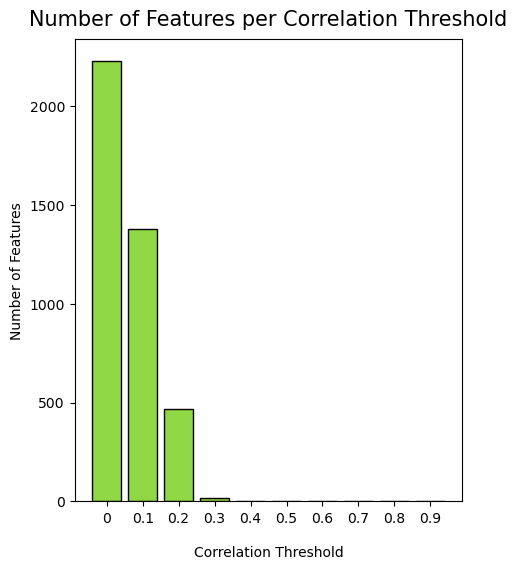

In [35]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.bar(threshold_df["Threshold"], threshold_df["Feature Count"], color="#8FD744FF", edgecolor="black")
ax.set_title("Number of Features per Correlation Threshold", fontsize = 15, pad=10)
ax.set_xlabel("Correlation Threshold", fontsize=10, labelpad=15)
ax.set_ylabel("Number of Features", fontsize=10)
plt.show()

In [36]:
rad_feature_names, rad_feature_correlations = spearman_df_function(rad_features, rad_class_cat, 0.29)

/tmp/ipykernel_33084/3746739423.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [37]:
spearman_df = pd.DataFrame(
    {
        "Features": rad_feature_names,
        "Correlations": rad_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,GLSZM_SzNonUnif_4gl,0.297295
1,GLSZM_GlVarianc_4gl,0.322953
2,GLSZM_GlNonUnif_8gl,0.300647
3,GLSZM_SzNonUnif_8gl,0.292724
4,GLSZM_SzoneLoGl_8gl,0.290713
5,GLSZM_GlVarianc_8gl,0.326366
6,GLRLM_RLN_8gl,0.316798
7,GLSZM_GlNonUnif_16gl,0.315822
8,GLRLM_RLN_16gl,0.304182
9,GLSZM_GlNonUnif_32gl,0.291932


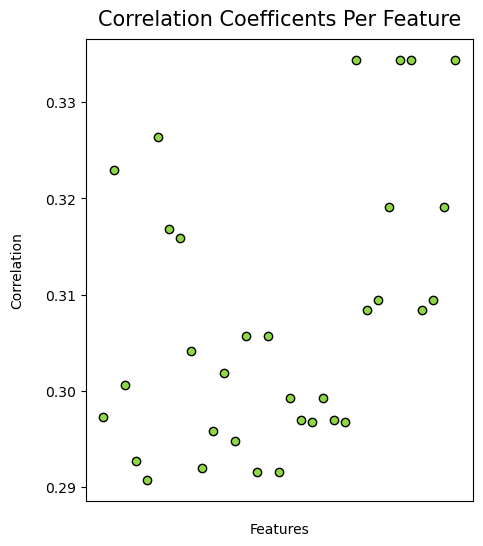

In [38]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.scatter(spearman_df["Features"], spearman_df["Correlations"], color="#8FD744FF", edgecolors="black")
ax.set_title("Correlation Coefficents Per Feature", fontsize = 15, pad=10)
ax.set_xlabel("Features", fontsize=10, labelpad=15)
ax.set_ylabel("Correlation", fontsize=10, labelpad=15)

plt.tick_params(bottom=False, labelbottom=False)
plt.show()

In [39]:
# Store spearman features
spearman_rad = spearman_df["Features"].to_list()

In [40]:
# Seperating out the features
X_train_rad = rad_train_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_train_rad = X_train_rad.loc[:, X_train_rad.columns.isin(spearman_rad)]
# Seperating out the target
y_train_rad = rad_train_df[["SURGICAL"]]

### Fit Random Forest Model

In [41]:
# Set the random state for reproducibility
fit_rf_rad = RandomForestClassifier(n_estimators=1000, 
                                    random_state=2)

In [ ]:
# Hyperparameter optimisation
param_dist = {"bootstrap": [True, False],
    "max_depth": [80, 90, 100, 110],
    "max_features": ["sqrt", "log2", 0.5, 0.7, None],
    "criterion": ["gini", "entropy"], 
    "class_weight": ["balanced", "balanced_subsample"]}

cv_rf_rad = GridSearchCV(fit_rf_rad, cv=3, param_grid=param_dist, verbose=3)

In [43]:
cv_rf_rad.fit(X_train_rad, y_train_rad.values.ravel())
print('Best Parameters using grid search: \n', 
      cv_rf_rad.best_params_)

`Best Parameters using grid search: 
 {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 80, 'max_features': 0.7}`

In [42]:
# Set best parameters given by grid search
fit_rf_rad.set_params(bootstrap = True,
                        criterion = "entropy",
                        class_weight = "balanced",
                        max_depth = 80,
                        max_features = 0.7)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=80, max_features=0.7, n_estimators=1000,
                       random_state=2)

### Out of Bag Error Rate

In [ ]:
fit_rf_rad.set_params(bootstrap = True,
                        n_estimators=100,
                        oob_score=True)

min_estimators = 10
max_estimators = 1000
min_oob_error = 1.0
min_index = 0

error_rate = {}

for i in range(min_estimators, max_estimators + 1):
    fit_rf_rad.set_params(n_estimators=i)
    fit_rf_rad.fit(X_train_rad, y_train_rad.values.ravel())

    oob_error = 1 - fit_rf_rad.oob_score_
    error_rate[i] = oob_error

    if min_oob_error > oob_error:
        min_oob_error = oob_error
        min_index = i

print("min_oob_error = ", min_oob_error)
print("min_index = ", min_index)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(min_estimators, max_estimators)
plt.plot(num_estimators, oob_error)
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 1000 trees)", fontsize=10)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(300, 800)
plt.plot(num_estimators, oob_error)
plt.axhline(0.232, color="red", linestyle="--")
plt.axhline(0.224, color="red", linestyle="--")
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 100 trees)", fontsize=10)
plt.show()

`n_estimatores` = 550

### Build Random Forest Model Using Best Parameters

In [43]:
# Create the classifier
fit_rf_rad.set_params(bootstrap = True,
                        n_estimators = 550, 
                        max_depth = 80,
                        max_features = 0.7,
                        criterion= "entropy",
                        class_weight = "balanced",
                        oob_score = True,
                        random_state = 2)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=80, max_features=0.7, n_estimators=550,
                       oob_score=True, random_state=2)

In [44]:
# Fit the model to the training set
fit_rf_rad.fit(X_train_rad, y_train_rad)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=80, max_features=0.7, n_estimators=550,
                       oob_score=True, random_state=2)

### Visualise Feature Importance

In [45]:
# Feature scores
feature_scores = pd.Series(fit_rf_rad.feature_importances_, index=X_train_rad.columns).sort_values(ascending=True)
feature_scores = feature_scores[feature_scores > 0]

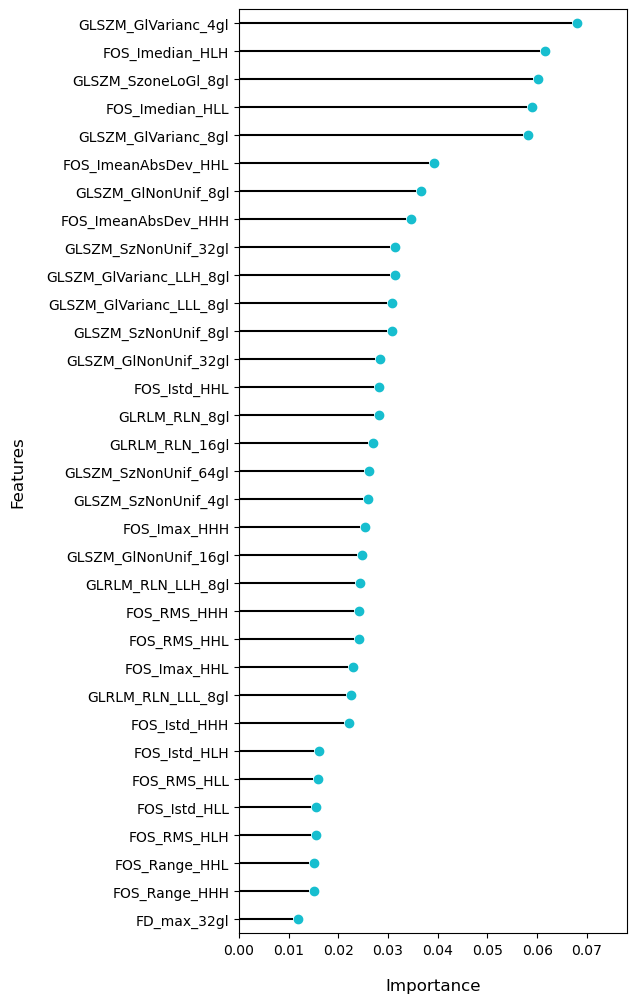

In [46]:
fig, ax = plt.subplots(figsize=(5, 12))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

ax.scatter(x=feature_scores, y=feature_scores.index, color="#17BECF")
miny, nexty, *_, maxy = ax.get_yticks()
eps = (nexty - miny) / 2 
ax.set_ylim(miny-eps, maxy+eps)
ax.set_xlim(0, max(feature_scores+0.01))
for x, y in zip(feature_scores, feature_scores.index):
    plt.hlines(y = y, xmin = 0, xmax = x-0.001, color="black") 
ax.tick_params(axis="both", which="major", labelsize=10)
ax.set_ylabel("Features", fontsize=12, labelpad=15)
ax.set_xlabel("Importance", fontsize=12, labelpad=15)

plt.show()


### Evaluate Model

#### Train

In [47]:
# Train 
y_train_rad_pred = pd.DataFrame(np.argmax(fit_rf_rad.oob_decision_function_,axis=1))
y_train_rad_pred.columns = ["SURGICAL"]
y_train_rad_pred["SURGICAL"] = y_train_rad_pred["SURGICAL"].map({1: "M-S", 0: "B-S"})
cmat = mx.confusion_matrix(y_train_rad, y_train_rad_pred)

In [48]:
printPerformance(cmat)

Accuracy = 0.7772
Precision = 0.5227
Recall = 0.2738
Specificity = 0.9261
False positive rate = 0.0739
F1-score = 0.3594
Confusion matrix (%):
[[71.47  5.71]
 [16.58  6.25]]


In [49]:
# Obtain the OOB error 
oob_error = 1 - fit_rf_rad.oob_score_ 
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

OOB error: 0.223


In [50]:
# Print classification report for model
print(classification_report(y_train_rad, y_train_rad_pred))

              precision    recall  f1-score   support

         B-S       0.81      0.93      0.87       284
         M-S       0.52      0.27      0.36        84

    accuracy                           0.78       368
   macro avg       0.67      0.60      0.61       368
weighted avg       0.75      0.78      0.75       368



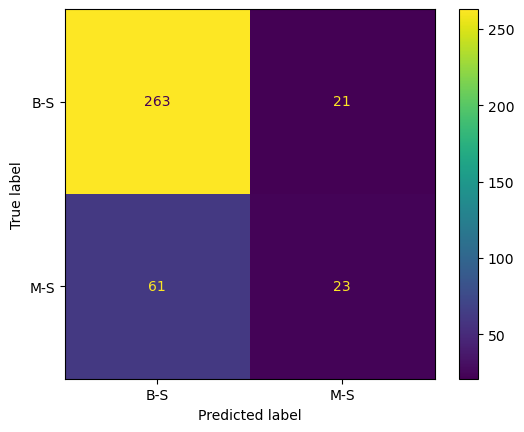

In [51]:
cm = confusion_matrix(y_train_rad, y_train_rad_pred, labels=fit_rf_rad.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rad.classes_)
disp.plot()

#### Test

In [52]:
# Test

# Seperating out the features
X_test_rad = rad_test_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_test_rad = X_test_rad.loc[:, X_test_rad.columns.isin(spearman_rad)]
# Seperating out the target
y_test_rad = rad_test_df[["SURGICAL"]]

y_test_rad_pred = fit_rf_rad.predict(X_test_rad)
cmat = mx.confusion_matrix(y_test_rad, y_test_rad_pred)

In [53]:
printPerformance(cmat)

Accuracy = 0.7586
Precision = 0.4667
Recall = 0.2593
Specificity = 0.9101
False positive rate = 0.0899
F1-score = 0.3333
Confusion matrix (%):
[[69.83  6.9 ]
 [17.24  6.03]]


In [54]:
# Obtain the OOB error 
oob_error = 1 - fit_rf_rad.oob_score_ 
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

OOB error: 0.223


In [55]:
# Print classification report for model
print(classification_report(y_test_rad, y_test_rad_pred))

              precision    recall  f1-score   support

         B-S       0.80      0.91      0.85        89
         M-S       0.47      0.26      0.33        27

    accuracy                           0.76       116
   macro avg       0.63      0.58      0.59       116
weighted avg       0.72      0.76      0.73       116



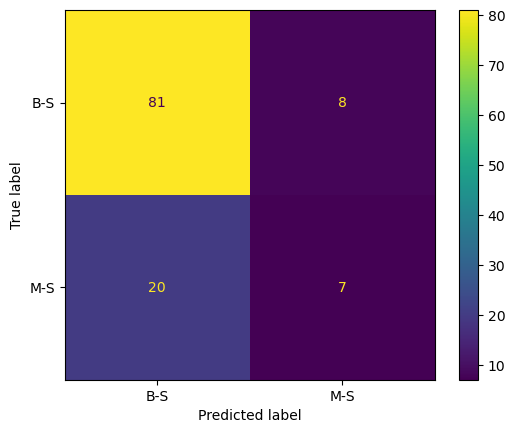

In [56]:
cm = confusion_matrix(y_test_rad, y_test_rad_pred, labels=fit_rf_rad.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rad.classes_)
disp.plot()

#### Validation

In [57]:
# Validation

# Seperating out the features
X_val_rad = rad_val_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_val_rad = X_val_rad.loc[:, X_val_rad.columns.isin(spearman_rad)]
# Seperating out the target
y_val_rad = rad_val_df[["SURGICAL"]]

y_val_rad_pred = fit_rf_rad.predict(X_val_rad)
cmat = mx.confusion_matrix(y_val_rad, y_val_rad_pred)

In [58]:
printPerformance(cmat)

Accuracy = 0.7935
Precision = 0.6000
Recall = 0.2857
Specificity = 0.9437
False positive rate = 0.0563
F1-score = 0.3871
Confusion matrix (%):
[[72.83  4.35]
 [16.3   6.52]]


In [59]:
# Obtain the OOB error 
oob_error = 1 - fit_rf_rad.oob_score_ 
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

OOB error: 0.223


In [60]:
# Print classification report for model
print(classification_report(y_val_rad, y_val_rad_pred))

              precision    recall  f1-score   support

         B-S       0.82      0.94      0.88        71
         M-S       0.60      0.29      0.39        21

    accuracy                           0.79        92
   macro avg       0.71      0.61      0.63        92
weighted avg       0.77      0.79      0.76        92



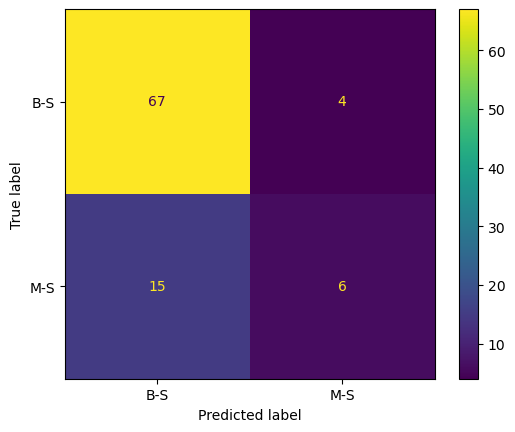

In [61]:
cm = confusion_matrix(y_val_rad, y_val_rad_pred, labels=fit_rf_rad.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rad.classes_)
disp.plot()

### Plot the ROC Curve

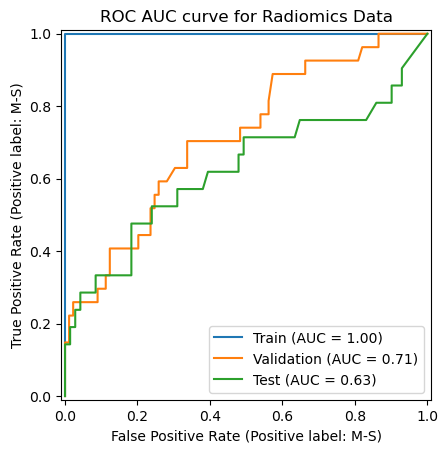

In [62]:
# Train data
disp = RocCurveDisplay.from_estimator(fit_rf_rad, X_train_rad, y_train_rad, pos_label='M-S', name="Train")

# Test data
disp = RocCurveDisplay.from_estimator(fit_rf_rad, X_test_rad, y_test_rad, pos_label='M-S', ax = disp.ax_, name="Validation")

# Validation data
disp = RocCurveDisplay.from_estimator(fit_rf_rad, X_val_rad, y_val_rad, pos_label='M-S', ax = disp.ax_, name="Test")

disp.ax_.set_title("ROC AUC curve for Radiomics Data");

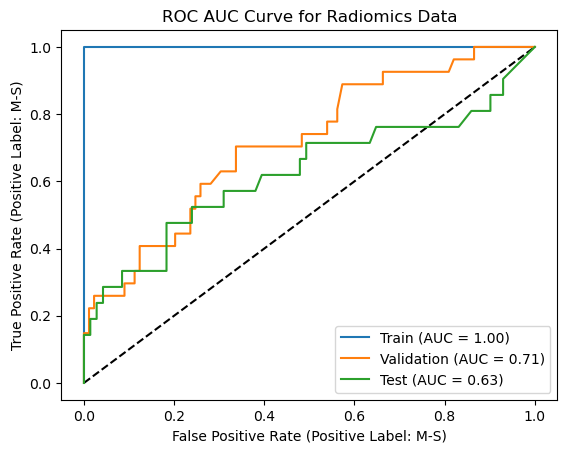

In [63]:
# Train
y_pred_prob1 = fit_rf_rad.predict_proba(X_train_rad)[:, 1]
fpr1, tpr1, thresholds1 = roc_curve(y_train_rad, y_pred_prob1, pos_label="M-S")
auc1 = roc_auc_score(y_train_rad, y_pred_prob1)

# Test
y_pred_prob2 = fit_rf_rad.predict_proba(X_test_rad)[:, 1]
fpr2, tpr2, thresholds2 = roc_curve(y_test_rad, y_pred_prob2, pos_label="M-S")
auc2 = roc_auc_score(y_test_rad, y_pred_prob2)

# Validate
y_pred_prob3 = fit_rf_rad.predict_proba(X_val_rad)[:, 1]
fpr3, tpr3, thresholds3 = roc_curve(y_val_rad, y_pred_prob3, pos_label="M-S")
auc3 = roc_auc_score(y_val_rad, y_pred_prob3)

plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr1, tpr1, label="Train (AUC = %0.2f)" % auc1)
plt.plot(fpr2, tpr2, label="Validation (AUC = %0.2f)" % auc2)
plt.plot(fpr3, tpr3, label="Test (AUC = %0.2f)" % auc3)

plt.legend()
plt.xlabel("False Positive Rate (Positive Label: M-S)")
plt.ylabel("True Positive Rate (Positive Label: M-S)")
plt.title('ROC AUC Curve for Radiomics Data')
plt.show()